In [1]:
#### Here we are evaluating concordance between proteomic and transcriptomics. 
### The hypothesis is that there should be little concordance and, as a proof of concept, we are checing this

import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.cluster import AgglomerativeClustering

In [2]:
clin = pd.read_csv('/Users/smasarone/Documents/jupyter_notebooks_copy2/clin_ready.csv', header = 0, index_col=0)
prot = pd.read_csv('/Users/smasarone/Documents/jupyter_notebooks_copy2/raw_data_proteins_filtered.csv',header = 0, index_col = 0)
prot_list = pd.read_csv('/Users/smasarone/Documents/jupyter_notebooks_copy2/prot_filtered.csv', header = 0, index_col=0)

prot = prot.filter(prot_list.iloc[:,0], axis = 1)
prot = prot.drop(labels = [1578], axis = 0) # outlier 
clin = clin.drop(labels = [1578], axis = 0)
prot.shape

# read rnaseq
counts = pd.read_csv('/Users/smasarone/Documents/omics_integration(PhD)/log_corrected_counts_trauma.tsv', delim_whitespace=True, index_col=0)
clin_rnaseq = pd.read_csv('/Users/smasarone/Documents/jupyter_notebooks_copy2/clin_rnaseq.csv',index_col=0)

# remove 1253 as it is an outlier
counts = counts.drop('S1253', axis = 1)

In [3]:
new_idx=[]
for i in prot.index:
    new_idx.append("S"+str(i))
prot.index = new_idx

# filter datasets
counts_common = counts.T.filter(items = prot.index, axis = 0)
prot_common = prot.filter(items = counts_common.index, axis = 0)

print(prot_common.shape)
print(counts_common.shape)

(412, 4979)
(412, 20782)


In [4]:
# check that all indices are the same
print(set(prot.index)-set(counts.columns))

{'S1628', 'S1253'}


In [5]:
### now try to get the first part of the name in the prot and check if that exists in the counts
counts_we_want =[]
prot_we_want =[]
for i in prot_common.columns:
    if i.split(".")[0] in counts_common:
        counts_we_want.append(i.split(".")[0])
        prot_we_want.append(i)

print("common names:",len(counts_we_want))

# scale data
scaler = StandardScaler()
scaler.fit(prot_common)
scaled_prot = scaler.transform(prot_common)
prot_s = pd.DataFrame(scaled_prot, index = prot_common.index)
prot_s.columns = prot_common.columns

# filter datasets by common genes
d1_counts = counts_common.filter(items=counts_we_want, axis = 1)
print(d1_counts.shape)
d2_prot = prot_common.filter(items=prot_we_want, axis = 1)
print(d2_prot.shape)
clin_fin = clin_rnaseq.filter(items = d2_prot.index, axis = 0)

# calculate corr 
new=[]
for i in d2_prot.columns:
    new.append(i.split(".")[0])
    
d2_prot.columns = new    
corrs = d1_counts.corrwith(d2_prot).round(2)
corrs.nlargest(30)

common names: 3967
(412, 3967)
(412, 3967)


MMP9        0.68
MDGA1       0.61
SIGLEC14    0.61
PRG3        0.59
FOLR3       0.54
LDHA        0.53
RETN        0.53
TNFAIP6     0.53
CEACAM8     0.51
ELANE       0.51
S100A12     0.51
CRISPLD2    0.48
LILRA3      0.48
RNASE3      0.48
NFKBID      0.47
TCN1        0.47
CLEC4C      0.46
IL1RN       0.46
AZU1        0.45
PTX3        0.45
CRISP3      0.44
PROK2       0.44
PYGL        0.43
DEFA1       0.42
SFRP1       0.42
MCEMP1      0.41
MX1         0.41
PLAUR       0.41
STAT3       0.41
OSM         0.40
dtype: float64

/usr/local/anaconda3/envs/phd_paper/lib/python3.8/site-packages/seaborn/distributions.py:2557: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function for histograms).
  warnings.warn(msg, FutureWarning)


Text(0.5, 0, 'Correlation')

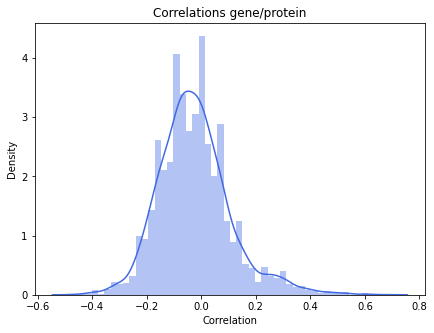

In [12]:
# plot a schematic of the distribution of correlations
plt.figure(figsize = (7, 5))
plt.title("Correlations gene/protein")
sns.distplot(corrs, color = 'royalblue') 
plt.xlabel("Correlation")

Text(0, 0.5, 'prot exp.')

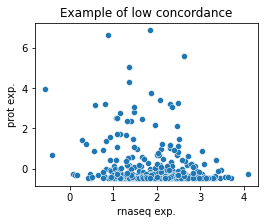

In [50]:
# example of low concordance
plt.figure(figsize = (4, 3))
plt.title('Example of low concordance')
sns.scatterplot(x = counts_common['PC'], y = prot_s['PC.13990.1'])
plt.xlabel("rnaseq exp.")
plt.ylabel("prot exp.") 

In [77]:
# print tables of correlations
corrs.nlargest(30).to_csv('top30.csv')

In [52]:
### cluster for sunkey plot 
scaler = StandardScaler()
d2_scaled = scaler.fit_transform(d2_prot)
d2_scaled_df = pd.DataFrame(d2_scaled, columns = d2_prot.columns, index = d2_prot.index)

d2_scaled_df.head(3)

,A1BG,A1CF,A2M,A2ML1,A4GALT,AAGAB,AASDHPPT,ABCC6,ABHD10,ABHD12,...,ZNF566,ZNF75D,ZNF774,ZNF843,ZNRF3,ZNRF3,ZPBP2,ZWILCH,ZWINT,ZYX
S1870,0.850519,0.009535,-0.172112,-0.224037,-0.483100,-0.770471,-0.959133,-0.423077,-0.718201,-0.437005,...,-0.471478,-0.276485,-0.467517,-0.413820,-0.404205,-0.487201,-0.516057,-0.589913,-0.614979,-0.665433
S1822,-0.301956,-0.551066,-0.070463,-0.190479,-0.366254,-0.737037,-0.618571,-0.460744,-0.711084,-0.475328,...,-0.494509,-0.475390,-0.479072,-0.472638,-0.338782,-0.453695,-0.551142,-0.580553,-0.553013,-0.730355
S326,-0.438943,-0.111599,1.542412,-0.129917,-0.225348,0.034851,0.035395,-0.051969,1.760717,-0.047041,...,-0.115656,-0.059413,-0.105331,-0.076891,0.028610,0.064573,-0.069986,0.238847,0.008845,0.695074


In [64]:
# agglomerative clustering to identify groups in the data
clustering = AgglomerativeClustering(n_clusters = 10).fit(d1_counts.T)
labels_counts = clustering.labels_

clustering2 = AgglomerativeClustering(n_clusters = 10).fit(d2_scaled_df.T) # d2_prot
labels_prot = clustering2.labels_

In [65]:
# they are in the exact same positions
df_labels = pd.DataFrame(labels_prot, index=d2_prot.columns, columns =['source'])
df_labels['target'] = labels_counts
df_labels['source'].unique()

array([9, 7, 4, 0, 5, 1, 8, 6, 2, 3])

In [66]:
tabella = pd.DataFrame(df_labels.groupby(['source', 'target'])['target'].count())
tabella.head(20)
tabella['target']

source  target
0       0         77
        1         75
        2         67
        3         13
        4         22
                  ..
9       5         45
        6         32
        7         26
        8          1
        9          2
Name: target, Length: 92, dtype: int64

In [73]:
final = pd.DataFrame(tabella.index.get_level_values(0), columns = ['source'])
final['target']= tabella.index.get_level_values(1)
final['value'] = tabella['target'].values

new_final =[]
for i in final['target']:
    new_final.append(i+10)
final['target'] = new_final

final.to_csv('/Users/smasarone/Documents/jupyter_notebooks_copy2/sankey2.csv')

# add names and export for R
mod20 = ['ProtM1', 'ProtM2','ProtM3','ProtM4','ProtM5','ProtM6','ProtM7','ProtM8','ProtM9','ProtM10',
        'GeneM1','GeneM2','GeneM3','GeneM4','GeneM5','GeneM6','GeneM7','GeneM8','GeneM9','GeneM10']
names = pd.DataFrame(mod20)
names.to_csv('/Users/smasarone/Documents/jupyter_notebooks_copy2/names2.csv')

In [72]:
final.groupby(['source']).sum()

,target,value
source,,
0,127,318
1,145,238
2,127,472
3,127,84
4,127,426
5,127,187
6,145,429
7,127,1513
8,108,86
